# 06 - Evaluation Expansion

## Objective

The purpose of this notebook is to expand the evaluation of the California home sale price prediction models beyond R² and examine how prediction accuracy varies across different home price ranges.

In this notebook, we will:

- Load the cleaned training, validation, and testing datasets created during preprocessing.
- Recreate the final tuned XGBoost model selected during advanced model development.
- Evaluate the final model using MAE, RMSE, R², MAPE, and MdAPE.
- Compare the final evaluation metrics across Linear Regression, Decision Tree, Random Forest, and XGBoost.
- Divide the testing properties into price bands based on actual sale prices.
- Calculate prediction errors separately for each price band.
- Identify the price ranges where the final model performs best and where prediction errors are larger.
- Export the final model comparison metrics to `metrics_summary.csv`.

This expanded evaluation provides a more detailed view of model performance than R² alone and helps determine whether prediction accuracy is consistent across different segments of the California housing market.

In [16]:
# ============================================
# Import required libraries
# ============================================

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    root_mean_squared_error,
    r2_score,
)

# Display all columns when inspecting DataFrames.
pd.set_option("display.max_columns", None)

## Load the Cleaned Datasets

The preprocessing pipeline produced separate training, validation, and testing datasets.

For the final XGBoost model, the training and validation datasets will be combined because hyperparameter selection was already completed using the validation period in the advanced-model notebook.

The testing dataset remains separate and is used only for final evaluation.

In [17]:
# ============================================
# Load the cleaned datasets
# ============================================

data_path = Path("../data")

train = pd.read_csv(
    data_path / "train_cleaned.csv"
)

validation = pd.read_csv(
    data_path / "validation_cleaned.csv"
)

test = pd.read_csv(
    data_path / "test_cleaned.csv"
)

print("Datasets loaded successfully!\n")

print(f"Training shape:   {train.shape}")
print(f"Validation shape: {validation.shape}")
print(f"Testing shape:    {test.shape}")

Datasets loaded successfully!

Training shape:   (324378, 104)
Validation shape: (11901, 104)
Testing shape:    (12710, 104)


## Prepare the Final Evaluation Data

`ClosePrice` is separated from the predictor variables because it represents the actual sale price the model is trying to predict.

The training and validation datasets are then combined to recreate the final development dataset used to train the selected XGBoost model.

The testing dataset remains separate for evaluation.

In [18]:
# ============================================
# Separate predictor variables and target
# ============================================

# Training data
X_train = train.drop(columns="ClosePrice")
y_train = train["ClosePrice"]

# Validation data
X_validation = validation.drop(columns="ClosePrice")
y_validation = validation["ClosePrice"]

# Testing data
X_test = test.drop(columns="ClosePrice")
y_test = test["ClosePrice"]

# Combine training and validation data because
# hyperparameter selection has already been completed.
X_train_final = pd.concat(
    [X_train, X_validation],
    ignore_index=True
)

y_train_final = pd.concat(
    [y_train, y_validation],
    ignore_index=True
)

print(f"Final training features: {X_train_final.shape}")
print(f"Final training target:   {y_train_final.shape}")

print()

print(f"Testing features:        {X_test.shape}")
print(f"Testing target:          {y_test.shape}")

Final training features: (336279, 103)
Final training target:   (336279,)

Testing features:        (12710, 103)
Testing target:          (12710,)


## Recreate the Final XGBoost Model

The advanced-model notebook identified XGBoost Version D as the strongest configuration using the validation dataset.

The selected hyperparameters were:

- **300 estimators**
- **Maximum tree depth of 8**
- **Learning rate of 0.1**

No additional hyperparameter tuning is performed in this notebook. The selected configuration is recreated using the combined training and validation data so that its final predictions can be analyzed in greater detail.

In [19]:
# ============================================
# Recreate the final XGBoost model
# ============================================

final_xgb = XGBRegressor(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

# Train the selected model using the combined
# training and validation datasets.
final_xgb.fit(
    X_train_final,
    y_train_final
)

print("Final XGBoost model trained successfully!")

Final XGBoost model trained successfully!


In [20]:
# ============================================
# Generate final test predictions
# ============================================

xgb_predictions = final_xgb.predict(
    X_test
)

print(
    f"Generated {len(xgb_predictions):,} "
    f"XGBoost test predictions."
)

Generated 12,710 XGBoost test predictions.


## Calculate Overall Evaluation Metrics

Model performance is evaluated using five complementary metrics:

- **R²** measures how much of the variation in actual sale prices is explained by the model.
- **MAE** measures the average prediction error in dollars.
- **RMSE** also measures prediction error in dollars but gives greater weight to larger errors.
- **MAPE** measures the average prediction error as a percentage of the actual sale price.
- **MdAPE** measures the median percentage error and is less affected by unusually large percentage errors.

MAPE and MdAPE are particularly useful when evaluating home prices because the same dollar error can have very different significance for lower-priced and higher-priced properties.

In [21]:
# ============================================
# Calculate overall XGBoost test metrics
# ============================================

xgb_mae = mean_absolute_error(
    y_test,
    xgb_predictions
)

xgb_rmse = root_mean_squared_error(
    y_test,
    xgb_predictions
)

xgb_r2 = r2_score(
    y_test,
    xgb_predictions
)

xgb_mape = mean_absolute_percentage_error(
    y_test,
    xgb_predictions
) * 100

xgb_mdape = np.median(
    np.abs(
        (y_test - xgb_predictions) /
        y_test
    )
) * 100

print("Final XGBoost Evaluation\n")

print(f"MAE:   ${xgb_mae:,.2f}")
print(f"RMSE:  ${xgb_rmse:,.2f}")
print(f"R²:    {xgb_r2:.4f}")
print(f"MAPE:  {xgb_mape:.2f}%")
print(f"MdAPE: {xgb_mdape:.2f}%")

Final XGBoost Evaluation

MAE:   $160,177.50
RMSE:  $307,515.58
R²:    0.9024
MAPE:  12.23%
MdAPE: 8.46%


## Compare Final Model Metrics

The final testing results from each model are consolidated into a single table to provide an overall comparison of predictive performance.

All four models were evaluated using the same final testing period. In addition to R², the comparison includes MAE, RMSE, MAPE, and MdAPE so that model performance can be evaluated using both dollar-based and percentage-based prediction errors.

Lower MAE, RMSE, MAPE, and MdAPE values indicate better performance, while a higher R² indicates better performance.

In [22]:
# ============================================
# Create final model metrics summary
# ============================================

metrics_summary = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        303048.15,
        222391.18,
        173400.42,
        xgb_mae
    ],
    "RMSE": [
        503601.63,
        445656.87,
        338823.49,
        xgb_rmse
    ],
    "R²": [
        0.7381,
        0.7949,
        0.8815,
        xgb_r2
    ],
    "MAPE": [
        27.47,
        16.41,
        13.14,
        xgb_mape
    ],
    "MdAPE": [
        20.57,
        10.59,
        8.98,
        xgb_mdape
    ]
})

metrics_summary.style.format({
    "MAE": "${:,.2f}",
    "RMSE": "${:,.2f}",
    "R²": "{:.4f}",
    "MAPE": "{:.2f}%",
    "MdAPE": "{:.2f}%"
}).hide(axis="index")

Model,MAE,RMSE,R²,MAPE,MdAPE
Linear Regression,"$303,048.15","$503,601.63",0.7381,27.47%,20.57%
Decision Tree,"$222,391.18","$445,656.87",0.7949,16.41%,10.59%
Random Forest,"$173,400.42","$338,823.49",0.8815,13.14%,8.98%
XGBoost,"$160,177.50","$307,515.58",0.9024,12.23%,8.46%


## Export the Metrics Summary

The final model comparison table is exported as `metrics_summary.csv`.

This file provides a compact summary of the final MAE, RMSE, R², MAPE, and MdAPE results for all four models.

In [23]:
# ============================================
# Export final model metrics
# ============================================

output_path = Path("../reports")

# Create the reports folder if it does not
# already exist.
output_path.mkdir(
    parents=True,
    exist_ok=True
)

metrics_summary.to_csv(
    output_path / "metrics_summary.csv",
    index=False
)

print(
    "metrics_summary.csv exported successfully!"
)

metrics_summary.csv exported successfully!


## Create Detailed Prediction Results

To examine model performance across different home price ranges, a detailed results table is created for each property in the testing dataset.

For every test observation, the table includes:

- The actual sale price.
- The XGBoost predicted sale price.
- The prediction error in dollars.
- The absolute prediction error.
- The absolute percentage error.

These observation-level errors will be used to compare model performance across price bands.

In [24]:
# ============================================
# Create detailed prediction results
# ============================================

evaluation_results = pd.DataFrame({
    "ActualPrice": y_test.to_numpy(),
    "PredictedPrice": xgb_predictions
})

# Calculate the signed prediction error.
# Positive values mean the model predicted too high,
# while negative values mean it predicted too low.
evaluation_results["Error"] = (
    evaluation_results["PredictedPrice"]
    - evaluation_results["ActualPrice"]
)

# Calculate the size of the dollar error
# regardless of direction.
evaluation_results["AbsoluteError"] = (
    evaluation_results["Error"].abs()
)

# Calculate each property's percentage error.
evaluation_results["AbsolutePercentageError"] = (
    evaluation_results["AbsoluteError"]
    / evaluation_results["ActualPrice"]
) * 100

evaluation_results.head()

,ActualPrice,PredictedPrice,Error,AbsoluteError,AbsolutePercentageError
0,2250000.0,1.968416e+06,-281584.12500,281584.12500,12.514850
1,851000.0,9.143906e+05,63390.62500,63390.62500,7.448957
2,950000.0,9.334870e+05,-16513.00000,16513.00000,1.738211
3,245000.0,3.271547e+05,82154.71875,82154.71875,33.532538
4,1175000.0,1.276556e+06,101555.50000,101555.50000,8.643021


## Create Home Price Bands

The testing properties are divided into five price bands based on their **actual sale prices**.

Quintiles are used so that each price band contains approximately 20% of the testing observations. This provides relatively balanced groups for comparing prediction performance across lower-priced, middle-priced, and higher-priced homes.

The five groups are labeled:

1. Lowest Price
2. Lower-Middle Price
3. Middle Price
4. Upper-Middle Price
5. Highest Price

Using actual sale prices to define the bands allows model errors to be evaluated according to the true market segment of each property.

In [25]:
# ============================================
# Divide properties into actual-price quintiles
# ============================================

price_band_labels = [
    "1 - Lowest Price",
    "2 - Lower-Middle Price",
    "3 - Middle Price",
    "4 - Upper-Middle Price",
    "5 - Highest Price"
]

evaluation_results["PriceBand"] = pd.qcut(
    evaluation_results["ActualPrice"],
    q=5,
    labels=price_band_labels
)

# Check how many properties fall into each band.
evaluation_results["PriceBand"].value_counts(
    sort=False
)

PriceBand
1 - Lowest Price          2545
2 - Lower-Middle Price    2546
3 - Middle Price          2561
4 - Upper-Middle Price    2524
5 - Highest Price         2534
Name: count, dtype: int64

In [26]:
# ============================================
# Inspect actual sale-price ranges by band
# ============================================

price_band_ranges = (
    evaluation_results
    .groupby(
        "PriceBand",
        observed=True
    )
    .agg(
        Properties=("ActualPrice", "size"),
        MinimumPrice=("ActualPrice", "min"),
        MaximumPrice=("ActualPrice", "max"),
        MedianPrice=("ActualPrice", "median")
    )
    .reset_index()
)

price_band_ranges.style.format({
    "MinimumPrice": "${:,.0f}",
    "MaximumPrice": "${:,.0f}",
    "MedianPrice": "${:,.0f}"
}).hide(axis="index")

PriceBand,Properties,MinimumPrice,MaximumPrice,MedianPrice
1 - Lowest Price,2545,"$190,000","$575,000","$450,000"
2 - Lower-Middle Price,2546,"$575,772","$800,000","$699,000"
3 - Middle Price,2561,"$801,000","$1,100,000","$925,000"
4 - Upper-Middle Price,2524,"$1,100,005","$1,650,000","$1,335,000"
5 - Highest Price,2534,"$1,652,500","$8,250,000","$2,335,000"


## Evaluate Performance by Price Band

Overall model metrics can hide differences in prediction accuracy across different portions of the housing market.

To examine this, the final XGBoost model is evaluated separately within each actual-price quintile.

For each price band, the analysis reports:

- Number of properties.
- Mean actual sale price.
- MAE.
- RMSE.
- MAPE.
- MdAPE.
- Mean signed error.

MAE and RMSE show the size of prediction errors in dollars, while MAPE and MdAPE make errors more comparable across homes with very different sale prices.

The mean signed error also indicates whether the model tends to overpredict or underpredict within each price range.

In [27]:
# ============================================
# Calculate evaluation metrics by price band
# ============================================

price_band_metrics = (
    evaluation_results
    .groupby(
        "PriceBand",
        observed=True
    )
    .agg(
        Properties=("ActualPrice", "size"),
        MeanActualPrice=("ActualPrice", "mean"),
        MAE=("AbsoluteError", "mean"),
        RMSE=(
            "Error",
            lambda x: np.sqrt(
                np.mean(x ** 2)
            )
        ),
        MAPE=(
            "AbsolutePercentageError",
            "mean"
        ),
        MdAPE=(
            "AbsolutePercentageError",
            "median"
        ),
        MeanError=(
            "Error",
            "mean"
        )
    )
    .reset_index()
)

price_band_metrics.style.format({
    "MeanActualPrice": "${:,.0f}",
    "MAE": "${:,.0f}",
    "RMSE": "${:,.0f}",
    "MAPE": "{:.2f}%",
    "MdAPE": "{:.2f}%",
    "MeanError": "${:,.0f}"
}).hide(axis="index")

PriceBand,Properties,MeanActualPrice,MAE,RMSE,MAPE,MdAPE,MeanError
1 - Lowest Price,2545,"$440,635","$58,109","$94,968",14.35%,7.91%,"$29,919"
2 - Lower-Middle Price,2546,"$693,248","$67,318","$100,671",9.77%,6.68%,"$16,867"
3 - Middle Price,2561,"$935,328","$102,533","$182,766",10.86%,7.57%,"$25,659"
4 - Upper-Middle Price,2524,"$1,352,511","$161,754","$222,130",11.95%,9.23%,"$5,497"
5 - Highest Price,2534,"$2,751,788","$412,677","$610,061",14.25%,11.72%,"$-193,703"


### Price Band Results

The price-band evaluation shows that XGBoost performance varies across different portions of the California housing market.

The **Lower-Middle Price** band, containing homes from approximately **$575,772 to $800,000**, achieved the strongest percentage-based performance. This group had the lowest **MAPE of 9.77%** and the lowest **MdAPE of 6.68%**, indicating that predictions were typically most accurate relative to actual sale prices within this range.

The **Lowest Price** band, ranging from **$190,000 to $575,000**, produced the lowest dollar-based errors, with an **MAE of $58,109** and **RMSE of $94,968**. However, its MAPE was higher at **14.35%**, showing that relatively small dollar errors can still represent larger percentage errors for lower-priced properties.

Prediction errors increased in dollar terms as home prices increased. The **Highest Price** band, ranging from approximately **$1.65 million to $8.25 million**, produced the largest **MAE of $412,677** and **RMSE of $610,061**. Its **MAPE of 14.25%** and **MdAPE of 11.72%** also indicate weaker percentage-based performance than the middle price ranges.

The mean signed error provides additional information about prediction direction. The first four price bands have positive mean errors, indicating a slight tendency toward **overprediction**. In contrast, the Highest Price band has a mean error of approximately **-$193,703**, indicating that the model tends to **underpredict the most expensive homes**.

Overall, XGBoost performs most consistently in the lower-middle and middle portions of the housing market, while prediction accuracy decreases toward the highest-priced properties.

## Visualize Percentage Error by Price Band

MAPE and MdAPE are compared across the five price bands to visualize how relative prediction accuracy changes across the housing market.

Lower values indicate more accurate predictions relative to actual sale prices.

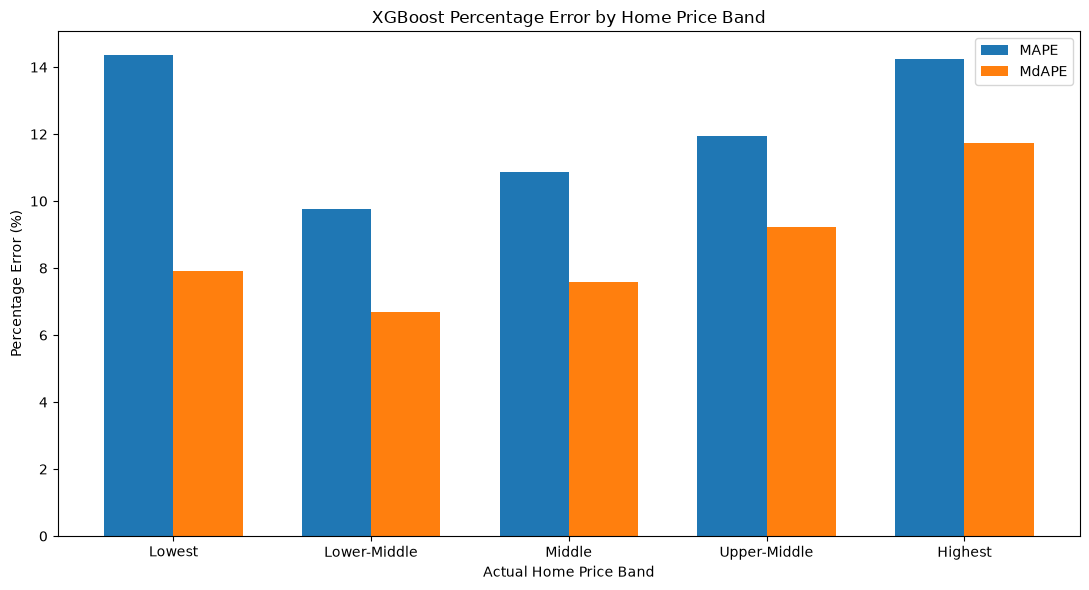

In [28]:
# ============================================
# Plot MAPE and MdAPE by price band
# ============================================

x = np.arange(
    len(price_band_metrics)
)

width = 0.35

plt.figure(figsize=(11, 6))

plt.bar(
    x - width / 2,
    price_band_metrics["MAPE"],
    width,
    label="MAPE"
)

plt.bar(
    x + width / 2,
    price_band_metrics["MdAPE"],
    width,
    label="MdAPE"
)

plt.xticks(
    x,
    [
        "Lowest",
        "Lower-Middle",
        "Middle",
        "Upper-Middle",
        "Highest"
    ]
)

plt.xlabel("Actual Home Price Band")
plt.ylabel("Percentage Error (%)")
plt.title(
    "XGBoost Percentage Error by Home Price Band"
)

plt.legend()

plt.tight_layout()
plt.show()

### Interpretation of Percentage Errors

The percentage-error comparison shows that prediction accuracy is not uniform across home price ranges.

Both MAPE and MdAPE are lowest in the **Lower-Middle Price** band, indicating that XGBoost provides its strongest relative prediction accuracy for homes between approximately **$576,000 and $800,000**.

Percentage errors are somewhat higher for the Lowest Price band, decrease for the lower-middle portion of the market, and then generally increase as home prices move into the upper price bands.

The Highest Price band has the largest MdAPE at **11.72%**, indicating that the typical percentage error is greatest among the most expensive homes.

The difference between MAPE and MdAPE within each price band also shows that some relatively large prediction errors increase the mean percentage error above the error experienced by the typical property.

## Visualize Dollar Error by Price Band

MAE and RMSE are also compared across the five price bands.

Unlike percentage-based metrics, these measures express prediction errors directly in dollars. This helps show how the financial size of prediction errors changes across different home values.

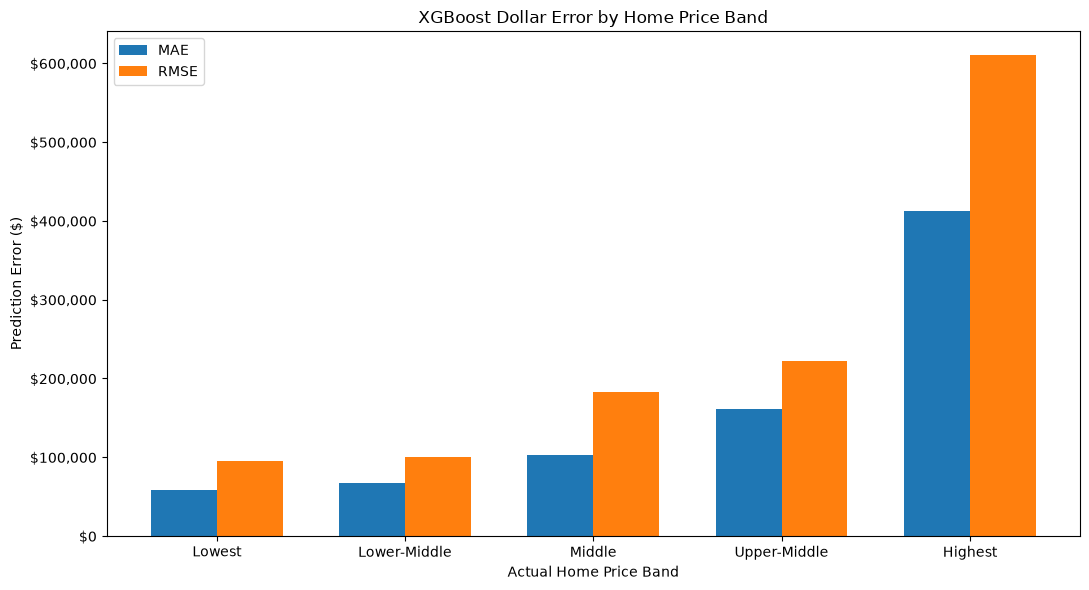

In [29]:
# ============================================
# Plot MAE and RMSE by price band
# ============================================

x = np.arange(
    len(price_band_metrics)
)

width = 0.35

plt.figure(figsize=(11, 6))

plt.bar(
    x - width / 2,
    price_band_metrics["MAE"],
    width,
    label="MAE"
)

plt.bar(
    x + width / 2,
    price_band_metrics["RMSE"],
    width,
    label="RMSE"
)

plt.xticks(
    x,
    [
        "Lowest",
        "Lower-Middle",
        "Middle",
        "Upper-Middle",
        "Highest"
    ]
)

plt.xlabel("Actual Home Price Band")
plt.ylabel("Prediction Error ($)")
plt.title(
    "XGBoost Dollar Error by Home Price Band"
)

plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, pos: f"${x:,.0f}"
    )
)

plt.legend()

plt.tight_layout()
plt.show()

### Interpretation of Dollar Errors

Dollar-based prediction errors increase substantially as home prices rise.

The Lowest Price band has the smallest errors, with an **MAE of approximately $58,109** and **RMSE of $94,968**. By comparison, the Highest Price band has an **MAE of approximately $412,677** and **RMSE of $610,061**.

The especially large RMSE in the Highest Price band indicates that some expensive properties have prediction errors substantially larger than the band's average absolute error.

This demonstrates why both dollar-based and percentage-based metrics are useful. Higher-priced homes can have large dollar errors even when their percentage errors remain within a range similar to other price segments.

## Prediction Direction by Price Band

The mean signed error indicates whether XGBoost tends to systematically overpredict or underpredict within each price range.

Because error was calculated as **Predicted Price - Actual Price**:

- A positive mean error indicates average **overprediction**.
- A negative mean error indicates average **underprediction**.

In [30]:
# ============================================
# Summarize prediction direction by price band
# ============================================

prediction_direction = (
    price_band_metrics[
        [
            "PriceBand",
            "MeanError"
        ]
    ]
    .copy()
)

prediction_direction["Direction"] = np.where(
    prediction_direction["MeanError"] > 0,
    "Overprediction",
    "Underprediction"
)

prediction_direction.style.format({
    "MeanError": "${:,.0f}"
}).hide(axis="index")

PriceBand,MeanError,Direction
1 - Lowest Price,"$29,919",Overprediction
2 - Lower-Middle Price,"$16,867",Overprediction
3 - Middle Price,"$25,659",Overprediction
4 - Upper-Middle Price,"$5,497",Overprediction
5 - Highest Price,"$-193,703",Underprediction


### Interpretation of Prediction Direction

The final XGBoost model slightly overpredicts sale prices on average across the first four price bands.

The Upper-Middle Price band is the closest to having no systematic directional error, with an average overprediction of only approximately **$5,497**.

The pattern changes substantially in the Highest Price band, where the model underpredicts sale prices by approximately **$193,703 on average**.

The results show that the model has greater prediction errors at the upper end of the California housing market and tends to produce predictions that are too conservative for the most expensive properties.

## Evaluation Insights

The expanded evaluation provides several insights that are not visible from R² alone:

1. **XGBoost remains the strongest overall model.**  
   It achieved an R² of **0.9024**, MAE of **$160,177.50**, RMSE of **$307,515.58**, MAPE of **12.23%**, and MdAPE of **8.46%** on the final testing dataset.

2. **The Lower-Middle Price band has the strongest relative accuracy.**  
   Homes between approximately **$576,000 and $800,000** achieved the lowest MAPE (**9.77%**) and MdAPE (**6.68%**).

3. **The Lowest Price band has the smallest dollar errors.**  
   Homes between **$190,000 and $575,000** produced the lowest MAE (**$58,109**) and RMSE (**$94,968**).

4. **Dollar errors increase substantially for expensive homes.**  
   The Highest Price band produced an MAE of approximately **$412,677** and RMSE of **$610,061**.

5. **The model tends to underpredict the most expensive properties.**  
   Homes above approximately **$1.65 million** had a mean signed error of approximately **-$193,703**, while the lower four price bands showed small average overpredictions.

6. **MAPE and MdAPE provide information that dollar-based metrics alone cannot show.**  
   Although the Lowest Price band has the smallest dollar errors, its MAPE is **14.35%**, which is higher than several more expensive price bands. This demonstrates that the significance of a dollar error depends on the underlying value of the property.

## Summary

In this notebook:

- The final tuned XGBoost model was recreated using the selected hyperparameters from the advanced-modeling stage.
- Overall model performance was evaluated using R², MAE, RMSE, MAPE, and MdAPE.
- Final metrics from Linear Regression, Decision Tree, Random Forest, and XGBoost were consolidated into a model comparison table.
- The model comparison was exported as `metrics_summary.csv`.
- The testing properties were divided into five actual-sale-price quintiles.
- XGBoost performance was evaluated separately within each price band using dollar-based and percentage-based error metrics.
- Prediction direction was examined to identify systematic overprediction and underprediction patterns.

The final XGBoost model achieved an **R² of 0.9024**, **MAE of $160,177.50**, **RMSE of $307,515.58**, **MAPE of 12.23%**, and **MdAPE of 8.46%**.

The expanded evaluation showed that model performance varies across the housing market. Relative prediction accuracy was strongest for homes in the **Lower-Middle Price** band of approximately **$576,000 to $800,000**, while the smallest dollar errors occurred among homes in the **Lowest Price** band.

The model showed its greatest difficulty with the **Highest Price** band above approximately **$1.65 million**, where dollar errors were substantially larger and predictions tended to underestimate actual sale prices.

These results demonstrate the importance of evaluating AVM performance across multiple metrics and market segments rather than relying on R² alone.